In [ ]:
import numpy as np
import pandas as pd
import pickle as pkl   
import matplotlib.pyplot as plt
from pymer4.models import Lmer
from matplotlib import patches
from utils import boxplot

In [ ]:
levels = pkl.load(open('data/LevelsFinal.pkl','rb'))
decision_time_data = pkl.load(open('data/ResultsTime.pkl','rb'))
subject_ids_convert_dict = pkl.load(open('data/AdditionalInfo.pkl','rb'))
players_data = pkl.load(open('data/ResultsPilot.pkl','rb'))
first_decision_point_data = pkl.load(open('data/ResultsFirstDecision.pkl','rb'))

In [18]:
# Focus on the first decision point
decision_time_data_first = decision_time_data[decision_time_data['PlatformType'] == 'FirstPlatform']

# Add the path length information to the dataframe
for i, p in enumerate(players_data):
    for l in p.level_results:
        id = subject_ids_convert_dict[p.prolific_ID]

        mask = (decision_time_data_first['Level'] == l) & (decision_time_data_first['SubjectID'] == id)
        still_time = decision_time_data_first.loc[mask,'StillTime'] 
        level_time = p.level_results[l].timepoints[-1, 0]
        decision_time_data_first.loc[mask,'LevelScore'] = level_time
        decision_time_data_first.loc[mask,'LevelPathLength'] = len(p.level_results[l].trajectory_platforms)


C:\Users\david\AppData\Local\Temp\ipykernel_62724\1630889056.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  decision_time_data_first.loc[mask,'LevelScore'] = level_time
C:\Users\david\AppData\Local\Temp\ipykernel_62724\1630889056.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  decision_time_data_first.loc[mask,'LevelPathLength'] = len(p.level_results[l].trajectory_platforms)


In [19]:
# Also add the infomation about the level type (and factors)
level_names = [l.level_name for l in levels]
decision_time_data_first['SmallShorter'] = pd.Series(dtype='int')
decision_time_data_first['SmallSmallerAngle'] = pd.Series(dtype='int')

for l in level_names:
    l_info = first_decision_point_data[first_decision_point_data['Level'] == l].iloc[0]
    decision_time_data_first.loc[decision_time_data_first['Level'] == l,'SmallShorter'] = int(l_info['SmallShorter'])
    decision_time_data_first.loc[decision_time_data_first['Level'] == l,'SmallSmallerAngle'] = int(l_info['SmallSmallerAngle'])

decision_time_data_first['SmallShorter'] = decision_time_data_first['SmallShorter'].astype(int)
decision_time_data_first['SmallSmallerAngle'] = decision_time_data_first['SmallSmallerAngle'].astype(int)


C:\Users\david\AppData\Local\Temp\ipykernel_62724\4274839754.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  decision_time_data_first['SmallShorter'] = pd.Series(dtype='int')
C:\Users\david\AppData\Local\Temp\ipykernel_62724\4274839754.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  decision_time_data_first['SmallSmallerAngle'] = pd.Series(dtype='int')
C:\Users\david\AppData\Local\Temp\ipykernel_62724\4274839754.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a 

In [20]:
# Linear mixed model of the path length over the "thinking time"
model = Lmer(f"LevelPathLength ~ StillTime + (1|SubjectID)", data=decision_time_data_first)
result_model = model.fit()
display(result_model)

# Subtract the random effects to get a normalized path length
random_effects_path_length = model.ranef.to_numpy()
path_length_norm = decision_time_data_first.groupby('SubjectID')['LevelPathLength'].mean().to_numpy() - random_effects_path_length[:,0] 

# Model for the still time as a function of the factors
model = Lmer(f"StillTime ~ SmallShorter + SmallSmallerAngle + (1|SubjectID)", data=decision_time_data_first)
result_model = model.fit(factors={'SmallShorter': ["0", "1"], 'SmallSmallerAngle': ["0","1"]})
display(result_model)

random_effects = model.ranef.to_numpy()
random_effects_variance = model.ranef_var['Var']['SubjectID']

# Pairwise comparisons
marginal_estimates, time_comparisons = model.post_hoc(
    marginal_vars=["SmallSmallerAngle", "SmallShorter"], p_adjust="tukey"
)


Linear mixed model fit by REML [’lmerMod’]
Formula: LevelPathLength~StillTime+(1|SubjectID)

Family: gaussian	 Inference: parametric

Number of observations: 1585	 Groups: {'SubjectID': 40.0}

Log-likelihood: -3360.172 	 AIC: 6728.345

Random effects:

                  Name    Var    Std
SubjectID  (Intercept)  0.544  0.737
Residual                3.864  1.966

No random effect correlations specified

Fixed effects:



c:\Users\david\OneDrive\Desktop\work\projects\Planning-While-Acting\.conda\Lib\site-packages\pymer4\models\Lmer.py:734: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),20.143,19.886,20.401,0.131,43.166,153.521,0.0,***
StillTime,-0.274,-0.366,-0.183,0.047,1484.095,-5.865,0.0,***


Linear mixed model fit by REML [’lmerMod’]
Formula: StillTime~SmallShorter+SmallSmallerAngle+(1|SubjectID)

Family: gaussian	 Inference: parametric

Number of observations: 1585	 Groups: {'SubjectID': 40.0}

Log-likelihood: -2357.811 	 AIC: 4725.622

Random effects:

                  Name    Var    Std
SubjectID  (Intercept)  0.459  0.677
Residual                1.061  1.030

No random effect correlations specified

Fixed effects:



c:\Users\david\OneDrive\Desktop\work\projects\Planning-While-Acting\.conda\Lib\site-packages\pymer4\models\Lmer.py:734: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.792,0.564,1.019,0.116,47.736,6.817,0.000,***
SmallShorter1,0.061,-0.040,0.163,0.052,1542.742,1.183,0.237,
SmallSmallerAngle1,-0.171,-0.272,-0.070,0.052,1542.730,-3.305,0.001,***


P-values adjusted by tukey method for family of 6 estimates


### Figure 4 - Analysis of the time spent on the first rock

40
LinregressResult(slope=np.float64(-0.35074969752719054), intercept=np.float64(20.19741394333172), rvalue=np.float64(-0.9065504123597591), pvalue=np.float64(8.225512935935478e-16), stderr=np.float64(0.026492710172221642), intercept_stderr=np.float64(0.02679302987969078))
[(0, 1, np.float64(0.005)), (1, 2, np.float64(0.008)), (2, 3, np.float64(0.005))]


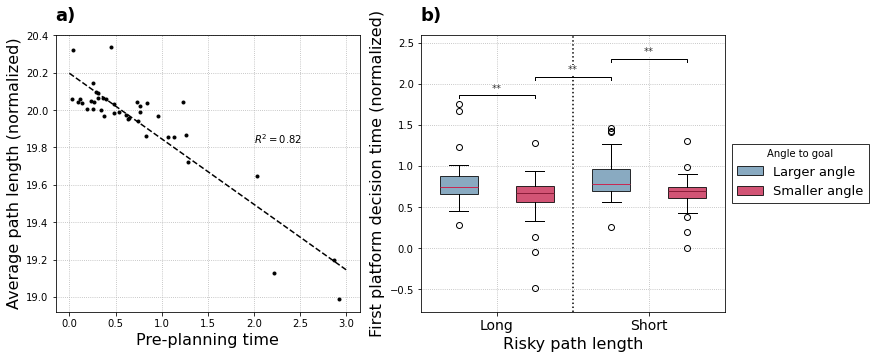

In [ ]:
color_blue_pastel = np.array([108, 149, 178])/255
color_bordeaux = np.array([199, 41, 83])/255
color_yellow_sunset = np.array([247, 200, 125])/255
color_red_crimson = np.array([215, 38, 56])/255


fig = plt.figure(figsize=(12,5), dpi=72)
gs = fig.add_gridspec(1,2, width_ratios=(0.5,0.5), hspace=0.4)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
axes = [ax1, ax2] 

plt.sca(ax1)
plt.plot(decision_time_data_first.groupby('SubjectID')['StillTime'].mean(), path_length_norm,'.', color='k')
plt.xlabel('Pre-planning time', fontsize=16)
plt.ylabel('Average path length (normalized)', fontsize=16)
plt.grid(True, linestyle=':')

from scipy.stats import linregress
# Faccio anche una regressione su tutto
x = decision_time_data_first.groupby('SubjectID')['StillTime'].mean().to_numpy()
res = linregress(x, path_length_norm)
m = res.slope
q = res.intercept
r = res.rvalue

y_pred = [q, m * 3 + q]
plt.plot([0,3], y_pred, '--', color='k')
plt.text(2,19.82,f'$R^2 = {r*r:.2f}$')

plt.sca(ax2)

box_colors = [color_blue_pastel, color_bordeaux] * 2
median_colors = [color_bordeaux, color_bordeaux * 0.7] * 2
xlabels = ['Long','Short']
legend_labels = ['Larger angle', 'Smaller angle']

ax = plt.gca()

# Estraggo i dati che mi interessano
time_variable = 'StillTime'

time_ss = decision_time_data_first[(decision_time_data_first['SmallShorter'] == 0) & (decision_time_data_first['SmallSmallerAngle'] == 0)]
time_sl = decision_time_data_first[(decision_time_data_first['SmallShorter'] == 0) & (decision_time_data_first['SmallSmallerAngle'] == 1)]
time_ls = decision_time_data_first[(decision_time_data_first['SmallShorter'] == 1) & (decision_time_data_first['SmallSmallerAngle'] == 0)]
time_ll = decision_time_data_first[(decision_time_data_first['SmallShorter'] == 1) & (decision_time_data_first['SmallSmallerAngle'] == 1)]

times_by_level_type = np.zeros((40,4))

for i in range(40):
    time_subj = time_ss[time_ss['SubjectID'] == i][time_variable]
    times_by_level_type[i,0] = time_subj.mean() - random_effects[i,0]

    time_subj = time_sl[time_sl['SubjectID'] == i][time_variable]
    times_by_level_type[i,1] = time_subj.mean() - random_effects[i,0]

    time_subj = time_ls[time_ls['SubjectID'] == i][time_variable]
    times_by_level_type[i,2] = time_subj.mean() - random_effects[i,0]

    time_subj = time_ll[time_ll['SubjectID'] == i][time_variable]
    times_by_level_type[i,3] = time_subj.mean() - random_effects[i,0]


significance_line_position = 'up'
pvals = time_comparisons['P-val']
sign_combinations = [(0,1,pvals.iloc[0]),(1,2,pvals.iloc[3]),(2,3,pvals.iloc[5])]
box_colors = box_colors*2
median_colors = median_colors*2

# Plot
boxplot(times_by_level_type, custom_significant_combinations=sign_combinations, boxes_alpha=0.8, box_colors=box_colors, median_colors=median_colors, significance_lines_position=significance_line_position, sep_multiplier=1, show_connecting_lines=False)

# Allargo un po' il range in modo da far respirare il plot
y_lim = plt.ylim()
y_range = (y_lim[1] - y_lim[0])
space = y_range * 0.05
y_lim_new = [y_lim[0] - space, y_lim[1] + space]
plt.ylim(y_lim_new)

plt.xticks([1.5,3.5], xlabels, fontsize=14)
plt.grid(True, linestyle=':')

plt.xlabel('Risky path length', fontsize=16)
plt.ylabel('First platform decision time (normalized)', fontsize=16)

plt.plot([2.5,2.5], y_lim_new,':k')


patch_1 = patches.Patch(facecolor=box_colors[0], alpha=0.8, edgecolor='k', label = legend_labels[0])
patch_2 = patches.Patch(facecolor=box_colors[1], alpha=0.8, edgecolor='k',  label = legend_labels[1])
plt.legend(handles = [patch_1, patch_2], loc='center left', fontsize=13, fancybox=False, edgecolor='k',
           title='Angle to goal', alignment='center', bbox_to_anchor=(1, 0.5))


# Aggiungo assi fittizi alle immagini
for i,l in enumerate(['a','b']):
    axes[i].text(0, 1.05, f'{l})', transform=axes[i].transAxes, size=18, weight='bold')
